# DD2424 - Assignment 1
This is the main notebook containing the training for the first assignment of DD2424.
## 1. Prelimenary testing
This section contains the prelimenary testing of all the code componenets, f.e. the forward and backward pass, training, ...

### Loading the dataset

In [1]:
from utils import load_batch
import matplotlib.pyplot as plt
import numpy as np

In [2]:
X, Y, y = load_batch("data_batch_1")

/home/josef/Uni/P4/deep_learning/DD2424-assignments/assignment1/src/utils.py:20: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


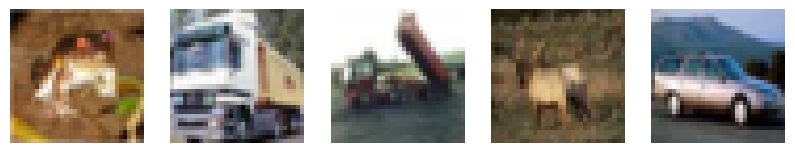

In [3]:
ni = 5
fig, axs = plt.subplots(1, 5, figsize=(10, 5))
for i in range(ni):
    X_im = X[:, i].reshape((32, 32, 3), order='F')
    X_im = np.transpose(X_im, (1, 0, 2))
    axs[i].imshow(X_im)
    axs[i].axis('off')
plt.pause(0.1)

### Scaling the dataset

In [4]:
from scaler import Scaler

scaler = Scaler()
X_train = scaler.fit_transform(X)

In [ ]:
# check if scaling was successful
print("The mean for the first 10 samples after scaling:")
print(np.mean(X_train, axis=1)[:10])
print("The standard deviation for the first 10 samples after scaling:")
print(np.std(X_train, axis=1)[:10])

### Testing forward pass

In [ ]:
from model import Model
model = Model(32*32*3, 10)
Y_pred = model.forward(X_train[:, :100])
Y_pred.shape

(10, 100)

In [ ]:
Y_pred[:,0]

array([ 0.05121096,  0.62430223,  0.37207589,  0.0456761 , -0.43508798,
       -0.38045104, -0.52871895,  0.16379476, -0.18598619,  0.07368599])

In [ ]:
from nodes import CrossEntropyLoss
loss_node = CrossEntropyLoss()

loss = loss_node.forward(Y_pred, Y[:, :100])
print(f"loss computed {loss}")

loss computed 2.4165355967198696


## Testing backward pass - gradient calculation

In [ ]:
grad = loss_node.backward()
print(grad.shape)

(10, 100)


In [ ]:
model.backward(grad)
my_W_grad = model.layers[0].grad_W.flatten()
my_b_grad = model.layers[0].grad_b.flatten()

In [ ]:
from torch_gradient_computations import ComputeGradsWithTorch
grads_torch = ComputeGradsWithTorch(X_train[:, :100], y[:100], model.layers[0].W, model.layers[0].b)
torch_W_grad = grads_torch['W'].flatten()
torch_b_grad = grads_torch['b'].flatten()

Loss computed with PyTorch: 2.416535596720


In [ ]:
from utils import calculate_mean_grad_difference

W_diff = calculate_mean_grad_difference(my_W_grad, torch_W_grad)
b_diff = calculate_mean_grad_difference(my_b_grad, torch_b_grad)
print(f"Mean absolute difference in W gradients: {W_diff}")
print(f"Mean absolute difference in b gradients: {b_diff}")

Mean absolute difference in W gradients: 2.1095277491209284e-16
Mean absolute difference in b gradients: 1.2746840824122078e-16


### Testing model training

In [ ]:
from optimizer import Optimizer
model = Model(32*32*3, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.001, reg=0.0)

In [ ]:
X, Y, y = load_batch("data_batch_1")
X_train = X[:, :7000]
y_train = y[:7000]
X_val = X[:, 7000:]
y_val = y[7000:]
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

/home/josef/Uni/P4/deep_learning/DD2424-assignments/assignment1/src/utils.py:20: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


In [ ]:
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=40, batch_size=100, print_every=50)

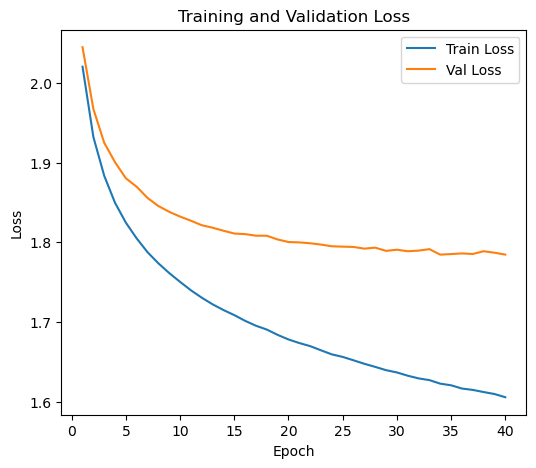

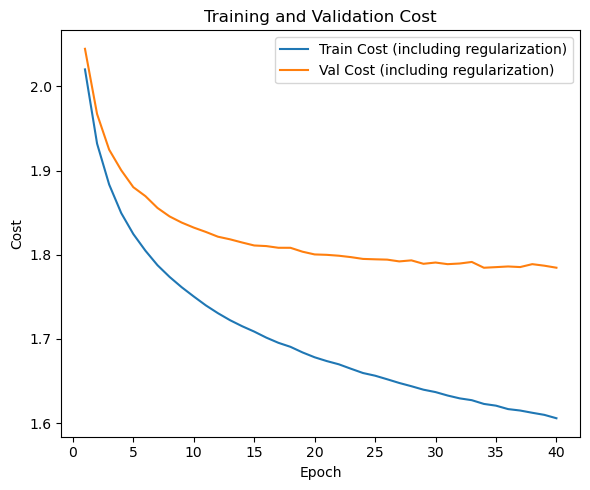

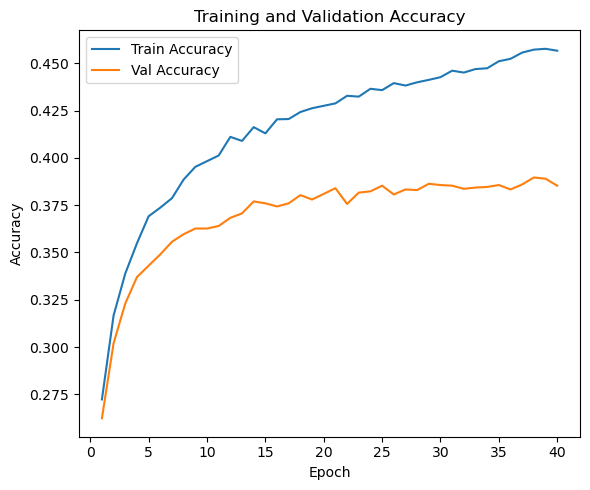

In [ ]:
optimizer.plot_training_progress()

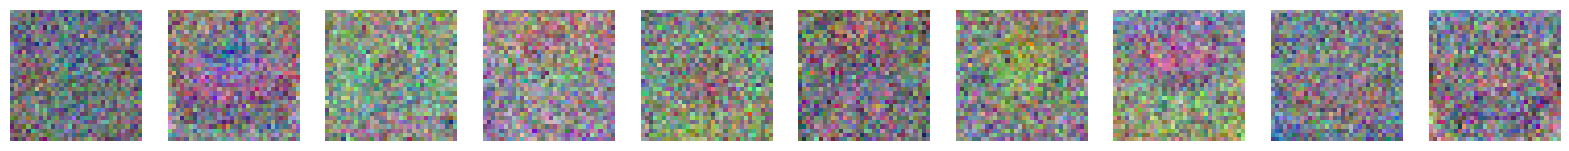

In [ ]:
import numpy as np
W = model.layers[0].W
W_im = W.transpose().reshape((32,32,3,10), order='F')
W_im = np.transpose(W_im, (1, 0, 2, 3))
plt.figure(figsize=(20, 20))
for i in range(10):
    w_im = W_im[:, :, :, i]
    w_im = (w_im - w_im.min()) / (w_im.max() - w_im.min())
    plt.subplot(1, 10, i+1)
    plt.imshow(w_im)
    plt.axis('off')

## 2. Assignment tasks
- Generate the graph of **loss**, **cost function**(loss + regularization), and **accuracy** on the training and testing data.
- Print the images representing the learnt weight matrix after training completion.
- Repeat for the following parameters:
  - lambda = 0, n_epochs = 40, n_batch = 100, lr = .1
  - lambda = 0, n_epochs = 40, n_batch = 100, lr = .001
  - lambda = 0.1, n_epochs = 40, n_batch = 100, lr = .001
  - lambda = 1, n_epochs = 40, n_batch = 100, lr = .001

In [ ]:
# Load the train and validation set
X_train, Y_train, y_train = load_batch("data_batch_1")
X_val, Y_val, y_val = load_batch("data_batch_2")
# scale the data
scaler = Scaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

#### A) lambda = 0, n_epochs = 40, n_batch = 100, lr = .1

In [ ]:
model = Model(32*32*3, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.1, reg=0.0)

In [ ]:
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=40, batch_size=100, print_every=5)

Epoch 5/40 - Train Loss: 5.9570, Val Loss: 6.9986, Train Acc: 0.3683, Val Acc: 0.2977
Epoch 10/40 - Train Loss: 6.0075, Val Loss: 7.4948, Train Acc: 0.3349, Val Acc: 0.2624
Epoch 15/40 - Train Loss: 3.8871, Val Loss: 5.6598, Train Acc: 0.3974, Val Acc: 0.2757
Epoch 20/40 - Train Loss: 5.4229, Val Loss: 7.2476, Train Acc: 0.3865, Val Acc: 0.2875
Epoch 25/40 - Train Loss: 4.0888, Val Loss: 6.1837, Train Acc: 0.4141, Val Acc: 0.2888
Epoch 30/40 - Train Loss: 4.0709, Val Loss: 6.3085, Train Acc: 0.4399, Val Acc: 0.3000
Epoch 35/40 - Train Loss: 4.3439, Val Loss: 6.7053, Train Acc: 0.4246, Val Acc: 0.2767
Epoch 40/40 - Train Loss: 4.9804, Val Loss: 7.5478, Train Acc: 0.4124, Val Acc: 0.2725


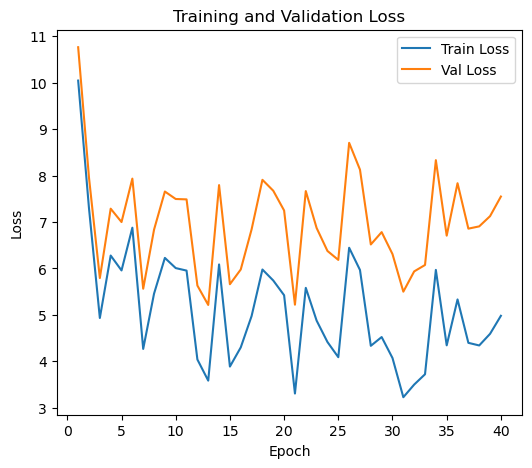

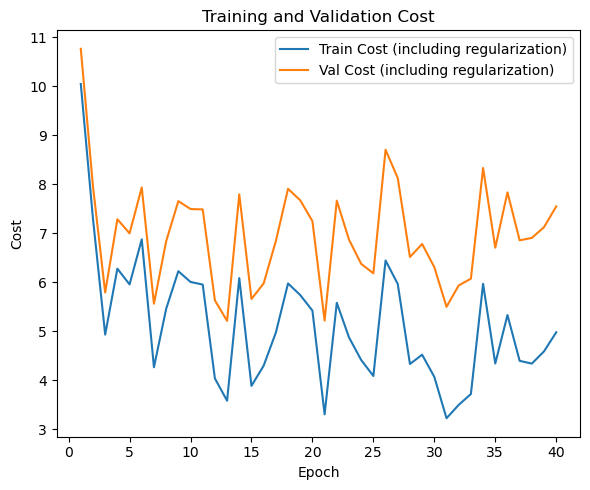

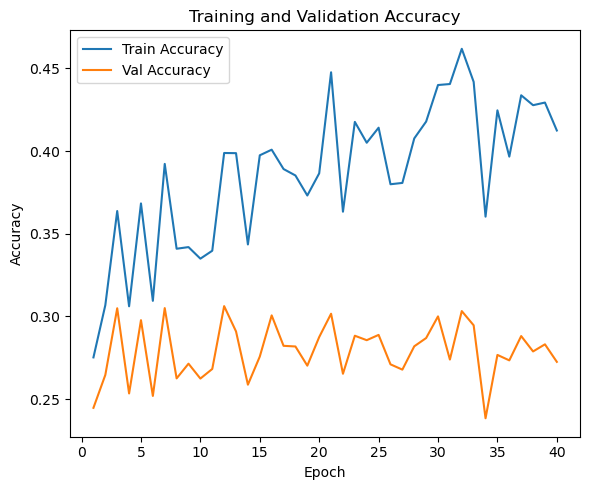

In [ ]:
optimizer.plot_training_progress()